In [1]:
!pip3 install moviepy
!pip3 install KDEpy


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip3 install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip3 install --upgrade pip


In [2]:
pip install matplotlib


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install seaborn


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
import ast
import matplotlib.pyplot as plt
import seaborn as sns
from moviepy import VideoFileClip
import numpy as np
import scipy.stats as stats
from scipy.signal import argrelextrema
from KDEpy import FFTKDE

In [6]:
video_1 = './video_1.mp4'
video_2 = './video_2.mp4'

In [7]:
def generate_density_dis(video_no, data,duration_seconds, segmentation_type):
    x_padding = 10
    time_points = np.linspace(0, duration_seconds, 1000)
    if segmentation_type== "coarse" : bw_values = [2.5,3,4,6]
    else: bw_values = [1.5,2,4,6]
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

    # Plot the smoothed density function
    fig, ax = plt.subplots(3, 1, figsize=(20, 10))  # 2 rows, 1 column
    ax[0].set_ylabel("Boundaries")
    ax[0].yaxis.set_ticks([])
    if segmentation_type == "coarse":
        color = '#B4CBF0'
    else: color = '#C9E6C0'
    for i, sublist in enumerate(data):
        for val in sublist:
            ax[0].axvline(x=val, color=color, linestyle='-')
    ax[0].set_xlim(-x_padding, duration_seconds + x_padding)
    ax[0].set_xlabel("time (in sec)")
    ax[0].spines['top'].set_visible(False)
    ax[0].spines['right'].set_visible(False)
    ax[0].set_title(f"Overall {segmentation_type} segmentation of Video_{video_no}")
    ax[0].legend()
    # #----------------------------------------------------------------------------------------------------------------
    data = np.array(np.concatenate(data))
    # Plot ax[1]
    ax[1].set_xlabel("time (in sec)")
    ax[1].set_ylabel("Button Press Density")
    ax[1].spines['top'].set_visible(False)
    ax[1].spines['right'].set_visible(False)
    ax[1].scatter(data, [0] * len(data), color='red', marker='o', s=5, label='Button Presses')
    for bw, color in zip(bw_values, colors):
        x, y = FFTKDE(kernel="gaussian", bw=bw).fit(data).evaluate()
        ax[1].plot(x, y, label=f'BW={bw}', color=color)
    ax[1].set_xlim(-x_padding, duration_seconds + x_padding)
    ax[1].set_title(f"Probability Density Distribution of {segmentation_type} segmentation of Video_{video_no}")
    ax[1].legend()

    #----------------------------------------------------------------------------------------------------------------
    local_maxima_points = []
    bw = 3 if segmentation_type == "coarse" else 2  # sec
    ax[2].set_xlabel("time (in sec)")
    ax[2].set_ylabel("Button Press Density")
    ax[2].spines['top'].set_visible(False)
    ax[2].spines['right'].set_visible(False)
    x, y = FFTKDE(kernel="gaussian", bw=bw).fit(data).evaluate()
    ax[2].plot(x, y, label=f'BW={bw}', color='#2ca02c')
    ax[2].set_xlim(-x_padding, duration_seconds + x_padding)
    ax[2].legend()

    # Plot local maxima points
    maxima_indices = argrelextrema(y, np.greater)[0]  # Find local maxima indices
    maxima_x = [x[i] for i in maxima_indices]  # Get corresponding x-coordinates
    maxima_y = [y[i] for i in maxima_indices]  # Get corresponding y-coordinates
    ax[2].scatter(maxima_x, maxima_y, marker='o', color='red', label='Local Maxima')
    local_maxima_points.extend(zip(maxima_x, maxima_y))  # Collect maxima points for reference
    # for mx, my in zip(maxima_x, maxima_y):
    #     ax[2].annotate((mx, my), textcoords="offset points", xytext=(5, 5), fontsize=8)
    #---------------------------------------------------------------------------------------------------------------
    plt.tight_layout()
    plt.show()

    return local_maxima_points

Function for calculating measures of segmentation agreement.
probability density of the button_presses and gaussian smoothing of the data points.

* -> takes video no. and video path as input, and coarse or fine grain segmentation.
* -> returns the segmentation agreement distributions and points of peaks.

In [8]:
def analysis(video_no, video_path, segmentation_type):
    fine_seg = []
    coarse_seg = []
    for i in range(1, 11):
        fine_segmentation_data,coarse_segmentation_data = [],[]
        csv_file = f'./video_{video_no}_data/0{i}.csv'
        df = pd.read_csv(csv_file)
             
        # fine_segmentation_data = ast.literal_eval(df.at[3, 'fine_segmentation_response.rt'])
        # coarse_segmentation_data = ast.literal_eval(df.at[4, 'coarse_segmentation_response.rt'])
        if(video_no == '1'):
            if(i==1 or i==3 or i==4 ):
                print(f'skipping the file {i}')
                continue
            csv_file = f'./video_{video_no}_data/0{i}.csv'
            df = pd.read_csv(csv_file)
            if ( i==2):
                fine_segmentation_data = ast.literal_eval(df.at[2, 'fine_segmentation_response.rt'])
                coarse_segmentation_data = ast.literal_eval(df.at[4, 'coarse_segmentation_response.rt'])
            else:
                fine_segmentation_data = ast.literal_eval(df.at[2, 'fine_segmentation_response.rt'])
                coarse_segmentation_data = ast.literal_eval(df.at[4, 'coarse_segmentation_response.rt'])
        
        if(video_no == '2'):
            if(i==1 or i==2 ):#3 fine 4 coarse
                csv_file = f'./video_{video_no}_data/0{i}.csv'
                df = pd.read_csv(csv_file)
                fine_segmentation_data = ast.literal_eval(df.at[1, 'fine_segmentation_response.rt'])
                coarse_segmentation_data = ast.literal_eval(df.at[2, 'coarse_segmentation_response.rt'])
                # print(f'skipping the file {i}')
                # continue
            elif(i==3):#fine 4 coarse 5
                csv_file = f'./video_{video_no}_data/0{i}.csv'
                df = pd.read_csv(csv_file)
                # print("***********FINE_GRAIN************")
                # print(df['fine_segmentation_response.rt'])
                # print("***********COARSE_GRAIN************")
                # print(df['coarse_segmentation_response.rt'])
                fine_segmentation_data = ast.literal_eval(df.at[2, 'fine_segmentation_response.rt'])
                coarse_segmentation_data = ast.literal_eval(df.at[3, 'coarse_segmentation_response.rt'])
            else: #fine 4 coarse 6
                csv_file = f'./video_{video_no}_data/0{i}.csv'
                df = pd.read_csv(csv_file)
                fine_segmentation_data = ast.literal_eval(df.at[2, 'fine_segmentation_response.rt'])
                coarse_segmentation_data = ast.literal_eval(df.at[4, 'coarse_segmentation_response.rt'])


        fine_segmentation_data = [int(x) for x in fine_segmentation_data if x >= 0] # converting the scale to 1ms
        coarse_segmentation_data = [int(x) for x in coarse_segmentation_data if x >= 0] # converting the scale to 1ms

        fine_seg.append(fine_segmentation_data)
        coarse_seg.append(coarse_segmentation_data)

    video = VideoFileClip(video_path)
    duration_seconds =int(video.duration) # converting to milli seconds.
    if segmentation_type == "coarse":
        data = coarse_seg
    else: data = fine_seg
    # print(data)
    # print(np.concatenate(data))
    #########################################################################################################################
    mean_clicks = [len(each_user) for each_user in data]
    N = int(sum(mean_clicks)/ len(mean_clicks)) # mean number of button presses by participants.
    print(f"mean number of button presses for {segmentation_type} task: {N}")
    ########################################################################################################################
    total_peaks =  generate_density_dis(video_no, data,duration_seconds, segmentation_type)
    # print(f"total peaks are {(total_peaks)}")
    normative_boundaries = sorted(total_peaks, key=lambda x: x[1], reverse=True)
    top_N_unique_pairs = []
    seen_second_items = set()
    for pair in normative_boundaries:
        if pair[1] not in seen_second_items:
            top_N_unique_pairs.append(pair[0])
            seen_second_items.add(pair[1])

        if len(top_N_unique_pairs) == N:
            break
    return sorted(top_N_unique_pairs)

{'video_found': True, 'audio_found': True, 'metadata': {'major_brand': 'mp42', 'minor_version': '1', 'compatible_brands': 'isommp41mp42', 'creation_time': '2024-11-04T05:55:43.000000Z'}, 'inputs': [{'streams': [{'input_number': 0, 'stream_number': 0, 'stream_type': 'video', 'language': None, 'default': True, 'size': [1440, 1080], 'bitrate': 2164, 'fps': 30.0, 'codec_name': 'h264', 'profile': '(Main)', 'metadata': {'Metadata': '', 'creation_time': '2024-11-04T05:55:43.000000Z', 'handler_name': 'Core Media Video', 'vendor_id': '[0][0][0][0]', 'encoder': 'Lavc60.3.100 libopenh264'}}, {'input_number': 0, 'stream_number': 1, 'stream_type': 'audio', 'language': None, 'default': True, 'fps': 48000, 'bitrate': 193, 'metadata': {'Metadata': '', 'creation_time': '2024-11-04T05:55:43.000000Z', 'handler_name': 'Core Media Audio', 'vendor_id': '[0][0][0][0]'}}], 'input_number': 0}], 'duration': 501.01, 'bitrate': 2360, 'start': 0.0, 'default_video_input_number': 0, 'default_video_stream_number': 0,

/var/folders/ft/j98pytps3pjfs7tl0t9bj6bc0000gn/T/ipykernel_64748/3286201621.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].legend()


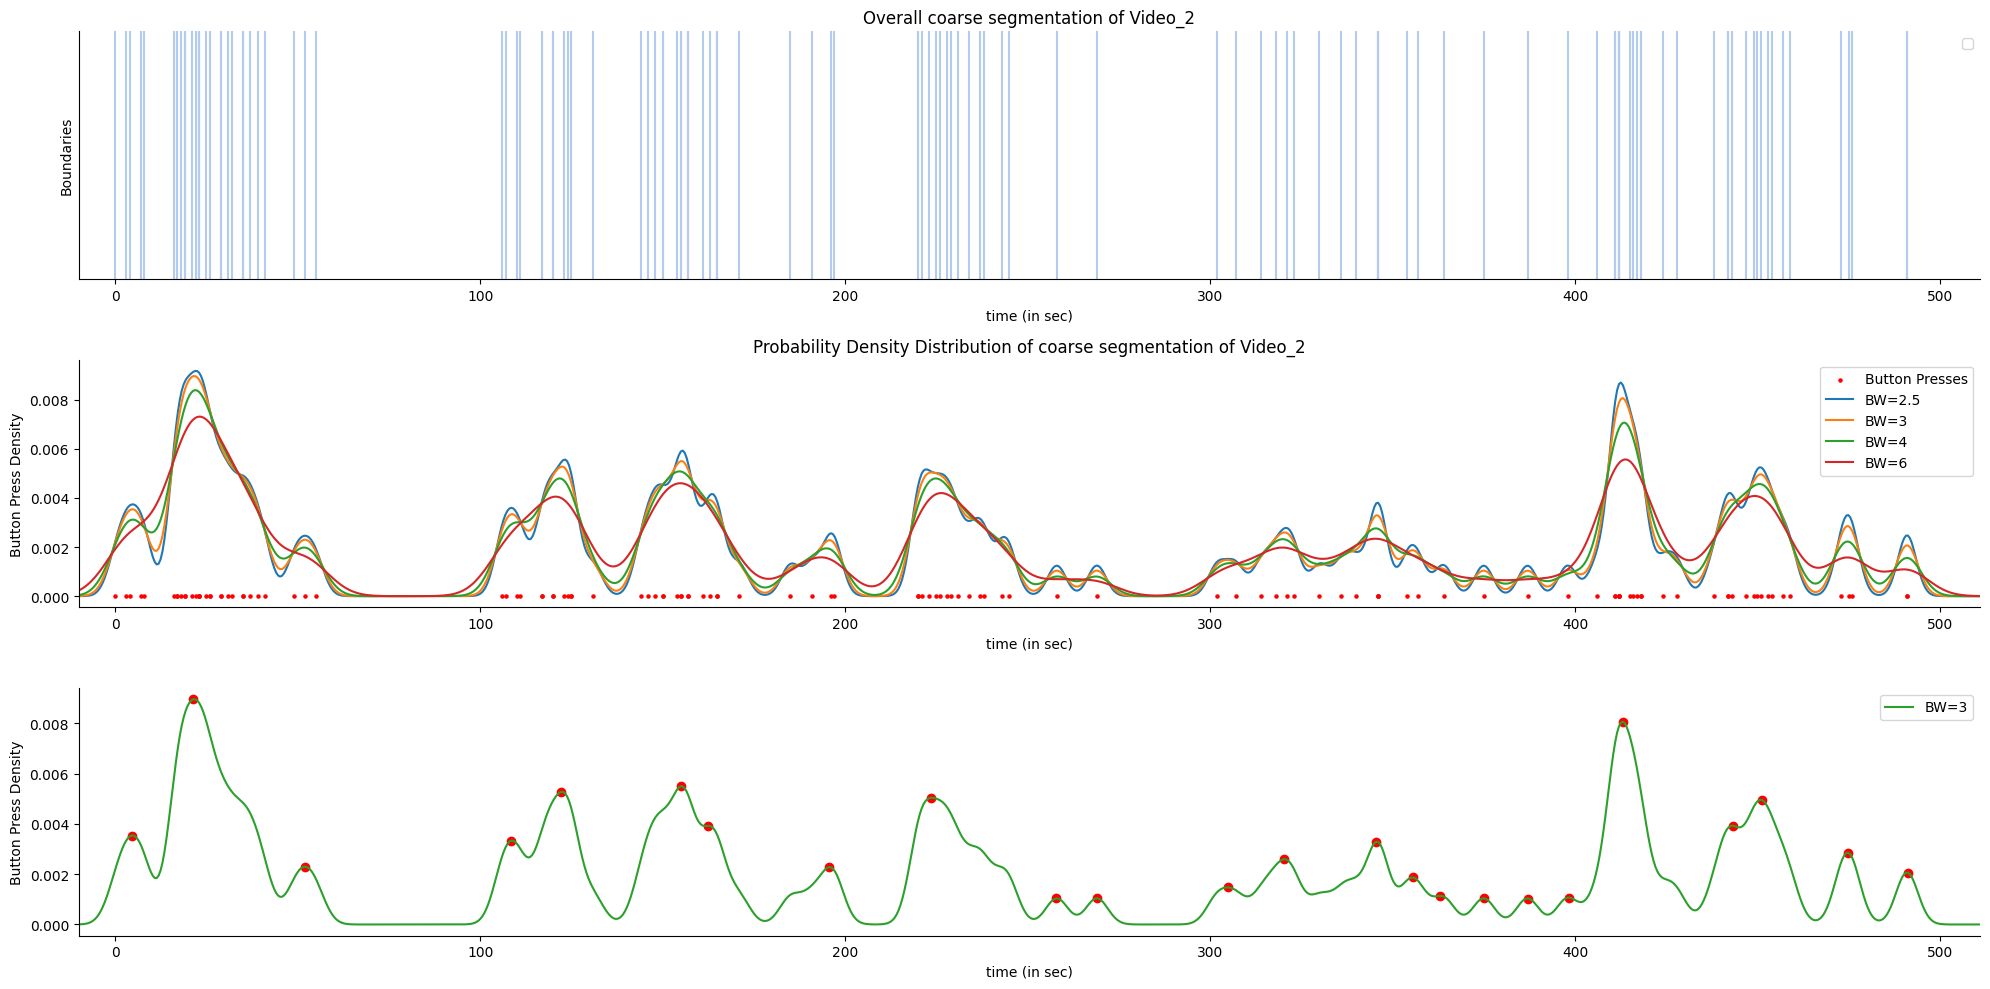

Time stamps for coarse grain: [np.float64(4.487634408602144), np.float64(21.38225806451612), np.float64(108.49516129032254), np.float64(122.22204301075267), np.float64(154.95537634408598), np.float64(162.34677419354833), np.float64(223.5897849462365), np.float64(345.5478494623655), np.float64(413.1263440860214), np.float64(443.2198924731182), np.float64(451.13924731182783), np.float64(474.89731182795686)]
{'video_found': True, 'audio_found': True, 'metadata': {'major_brand': 'mp42', 'minor_version': '1', 'compatible_brands': 'isommp41mp42', 'creation_time': '2024-11-04T05:55:43.000000Z'}, 'inputs': [{'streams': [{'input_number': 0, 'stream_number': 0, 'stream_type': 'video', 'language': None, 'default': True, 'size': [1440, 1080], 'bitrate': 2164, 'fps': 30.0, 'codec_name': 'h264', 'profile': '(Main)', 'metadata': {'Metadata': '', 'creation_time': '2024-11-04T05:55:43.000000Z', 'handler_name': 'Core Media Video', 'vendor_id': '[0][0][0][0]', 'encoder': 'Lavc60.3.100 libopenh264'}}, {'i

/var/folders/ft/j98pytps3pjfs7tl0t9bj6bc0000gn/T/ipykernel_64748/3286201621.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].legend()


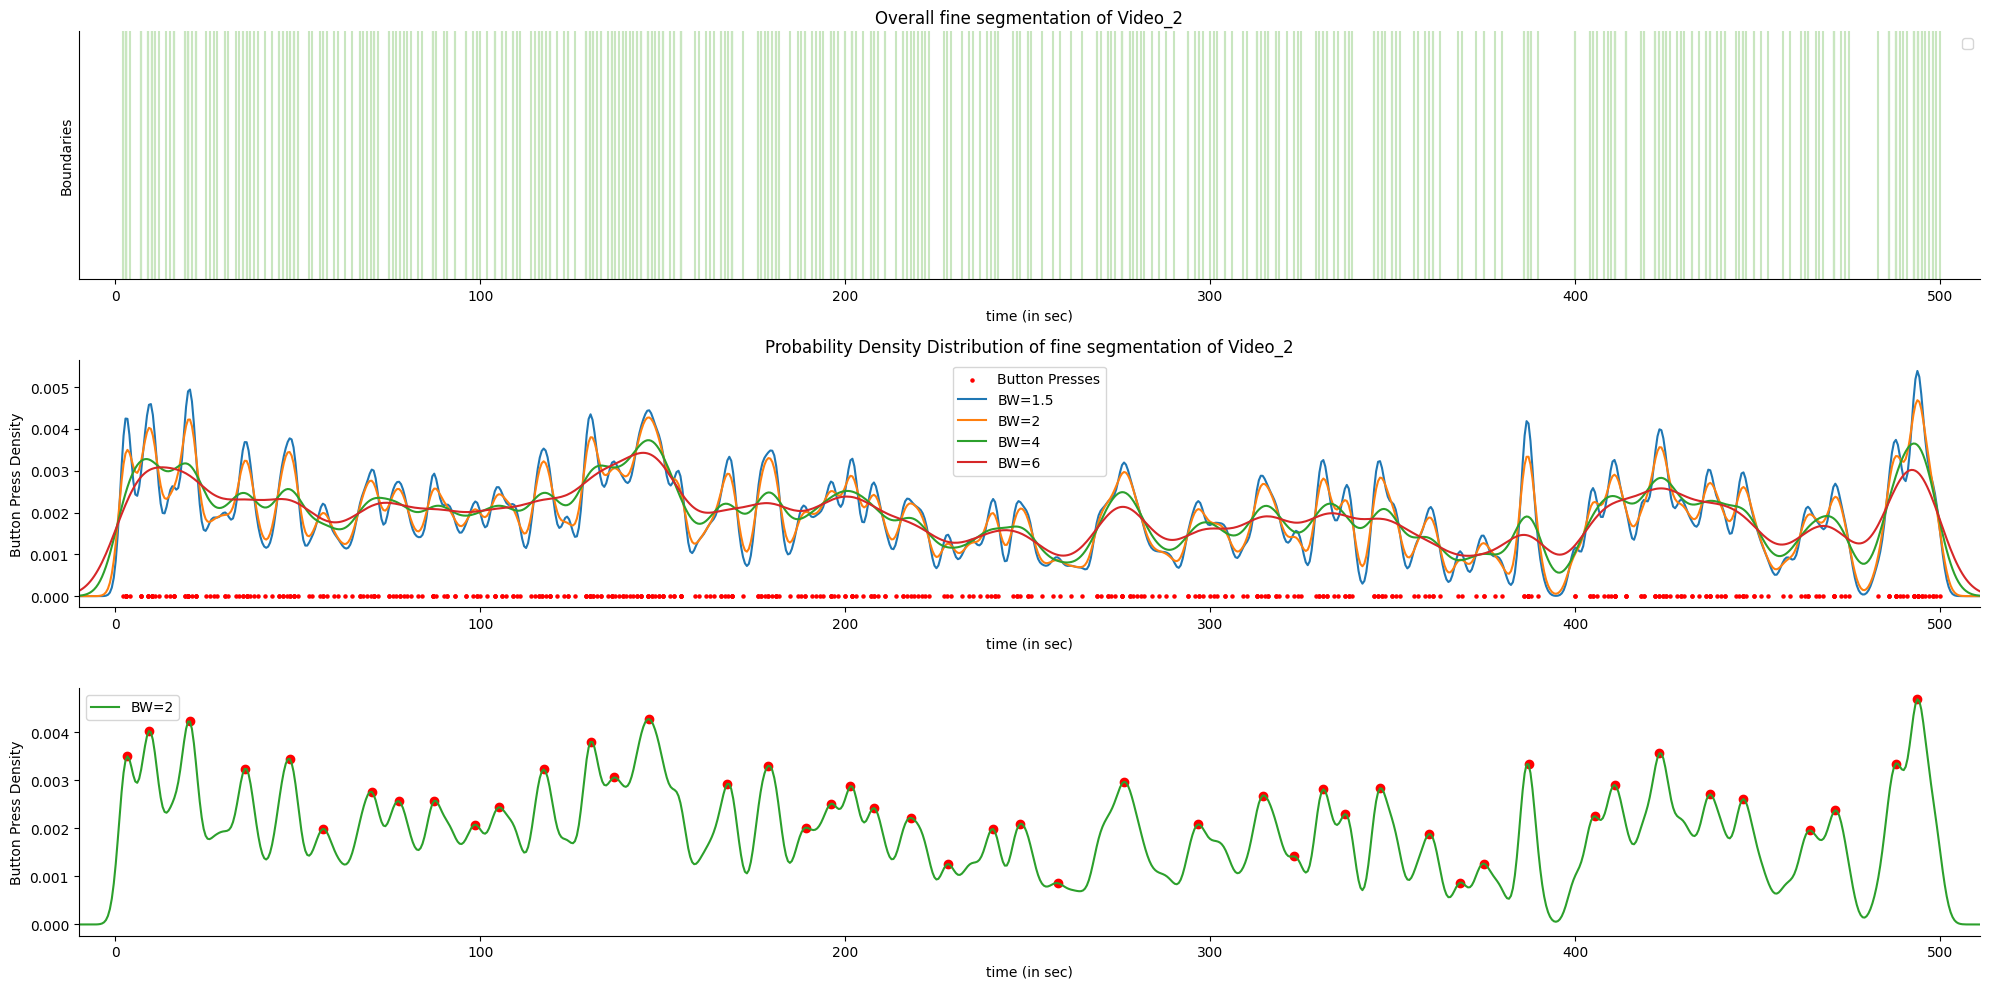

Time stamps for fine grain: [np.float64(3.3387096774193488), np.float64(9.22903225806451), np.float64(20.47419354838709), np.float64(35.46774193548386), np.float64(47.78387096774192), np.float64(56.88709677419354), np.float64(70.27419354838707), np.float64(77.77096774193546), np.float64(87.40967741935482), np.float64(98.65483870967739), np.float64(105.08064516129029), np.float64(117.39677419354837), np.float64(130.24838709677417), np.float64(136.67419354838708), np.float64(146.31290322580642), np.float64(167.7322580645161), np.float64(178.97741935483867), np.float64(189.15161290322578), np.float64(196.1129032258064), np.float64(201.46774193548384), np.float64(207.89354838709673), np.float64(218.06774193548384), np.float64(228.24193548387092), np.float64(240.558064516129), np.float64(248.0548387096774), np.float64(258.2290322580645), np.float64(276.43548387096774), np.float64(296.7838709677419), np.float64(314.4548387096774), np.float64(323.02258064516127), np.float64(331.05483870967737

In [9]:
peaks_coarse_2 = analysis('2',video_2,'coarse')
print("Time stamps for coarse grain:", peaks_coarse_2)
peaks_fine_2 = analysis('2', video_2,'fine')
print("Time stamps for fine grain:", peaks_fine_2)

In [10]:
#grouping timestamps into an array within an array so that it can be fed into the main analysis script, cutting them into 120s windows. input coarse time stamps
#Time stamps for coarse grain: [(21.798387096774192), (74.11451612903227), (93.09193548387097), (114.63387096774196), (146.9467741935484), (180.28548387096777), (195.6725806451613), (204.90483870967745), (265.94032258064516), (304.408064516129), (345.44032258064516), (356.7241935483871), (377.24032258064517), (397.2435483870968), (432.6338709677419), (442.3790322580645)]
#Time stamps for coarse grain video_2: [np.float64(4.487634408602144), np.float64(21.38225806451612), np.float64(108.49516129032254), np.float64(122.22204301075267), np.float64(154.95537634408598), np.float64(162.34677419354833), np.float64(223.5897849462365), np.float64(345.5478494623655), np.float64(413.1263440860214), np.float64(443.2198924731182), np.float64(451.13924731182783), np.float64(474.89731182795686)]

timestamps = [
    4.487634408602144, 21.38225806451612, 108.49516129032254, 122.22204301075267,
    154.95537634408598, 162.34677419354833, 223.5897849462365, 345.5478494623655,
    413.1263440860214, 443.2198924731182, 451.13924731182783, 474.89731182795686,  
]

# Time stamps for coarse grain video 2: 
# [(4.487634408602144), (21.38225806451612), (108.49516129032254), 
# (122.22204301075267), (154.95537634408598), (162.34677419354833), (223.5897849462365), 
# (345.5478494623655), 
# (413.1263440860214), (443.2198924731182), (451.13924731182783), (474.89731182795686)]



segments = []
current_segment = []
segment_start = 0
segment_end = 120

for ts in timestamps:
    while ts >= segment_end:
        segments.append(current_segment)
        current_segment = []
        segment_start = segment_end
        segment_end += 120
    current_segment.append(round(ts - segment_start, 6))

if current_segment:
    segments.append(current_segment)

video_eb_1 = segments

print(video_eb_1)


[[4.487634, 21.382258, 108.495161], [2.222043, 34.955376, 42.346774, 103.589785], [105.547849], [53.126344, 83.219892, 91.139247, 114.897312]]


mean number of button presses for coarse task: 16


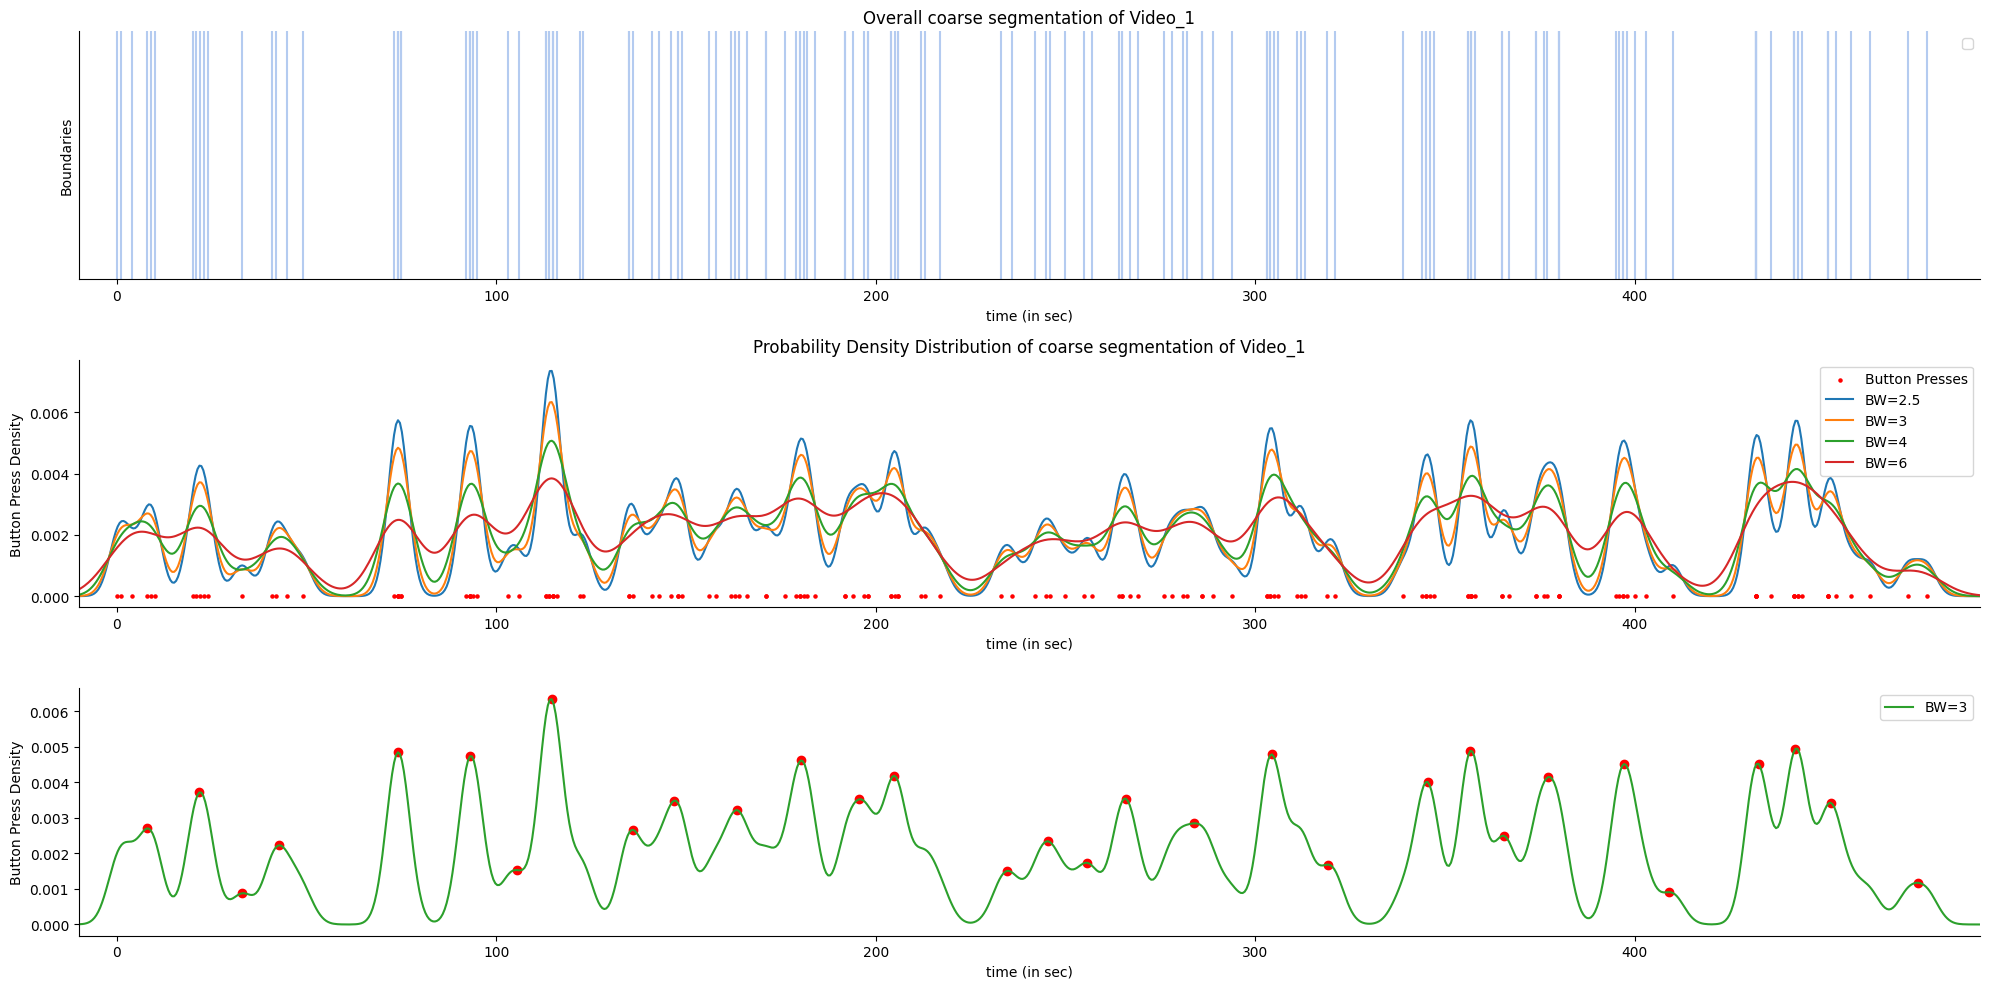

Time stamps for coarse grain: [np.float64(21.798387096774192), np.float64(74.11451612903227), np.float64(93.09193548387097), np.float64(114.63387096774196), np.float64(146.9467741935484), np.float64(180.28548387096777), np.float64(195.6725806451613), np.float64(204.90483870967745), np.float64(265.94032258064516), np.float64(304.408064516129), np.float64(345.44032258064516), np.float64(356.7241935483871), np.float64(377.24032258064517), np.float64(397.2435483870968), np.float64(432.6338709677419), np.float64(442.3790322580645)]
mean number of button presses for fine task: 33


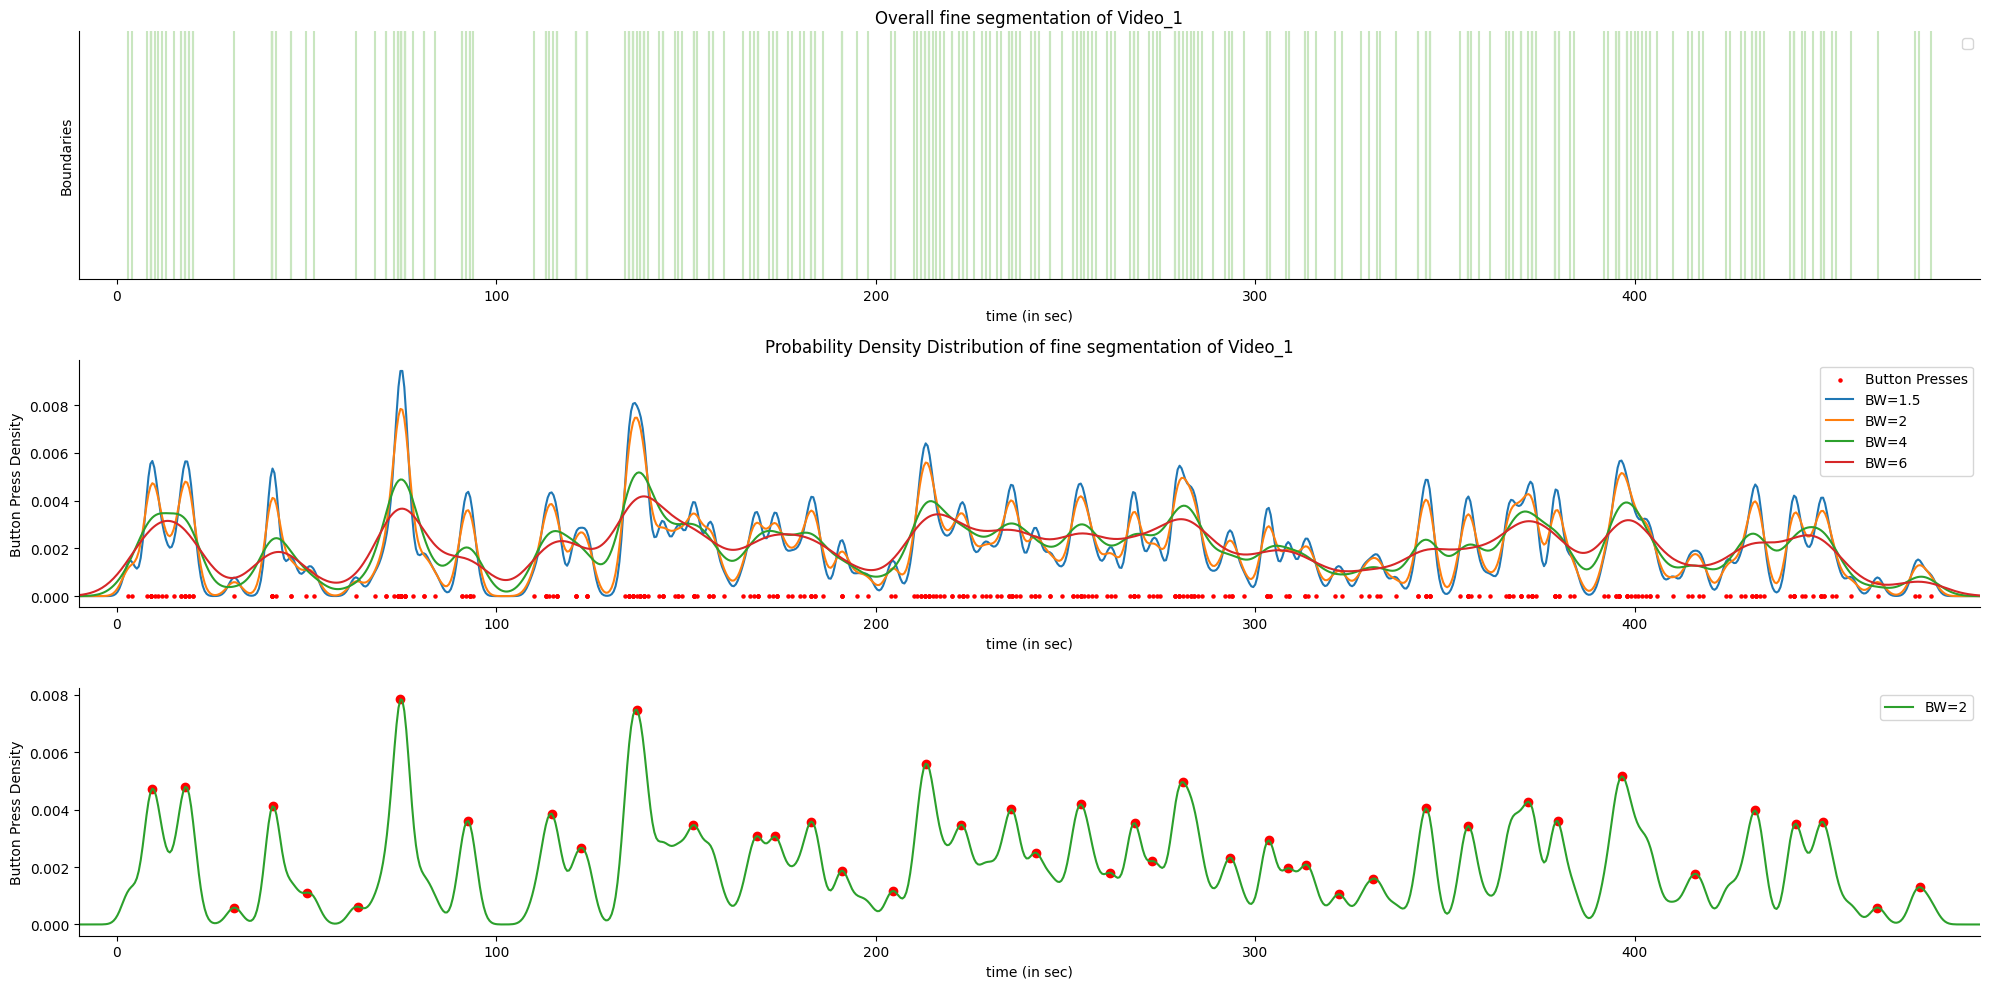

Time stamps for fine grain: [np.float64(9.384408602150536), np.float64(18.067204301075265), np.float64(41.0510752688172), np.float64(74.76075268817205), np.float64(92.63709677419355), np.float64(114.59946236559139), np.float64(122.26075268817203), np.float64(137.07258064516128), np.float64(151.88440860215053), np.float64(168.73924731182797), np.float64(173.33602150537635), np.float64(183.04032258064515), np.float64(191.21236559139786), np.float64(213.17473118279568), np.float64(222.36827956989248), np.float64(235.64784946236557), np.float64(242.28763440860217), np.float64(254.0349462365591), np.float64(268.3360215053763), np.float64(272.93279569892474), np.float64(281.10483870967744), np.float64(293.36290322580646), np.float64(303.5779569892473), np.float64(308.68548387096774), np.float64(313.2822580645161), np.float64(344.9489247311828), np.float64(356.18548387096774), np.float64(372.01881720430106), np.float64(379.6801075268817), np.float64(396.5349462365591), np.float64(431.77688172

In [10]:
# D:\research_materials\experiments
peaks_coarse_1 = analysis('1',video_1,'coarse')
print("Time stamps for coarse grain:", peaks_coarse_1)
peaks_fine_1 = analysis('1', video_1,'fine')
print("Time stamps for fine grain:", peaks_fine_1)

In [ ]:
#grouping timestamps into an array within an array so that it can be fed into the main analysis script, cutting them into 120s windows. input coarse time stamps
#Time stamps for coarse grain: [(21.798387096774192), (74.11451612903227), (93.09193548387097), (114.63387096774196), (146.9467741935484), (180.28548387096777), (195.6725806451613), (204.90483870967745), (265.94032258064516), (304.408064516129), (345.44032258064516), (356.7241935483871), (377.24032258064517), (397.2435483870968), (432.6338709677419), (442.3790322580645)]

timestamps = [
    21.798387096774192, 74.11451612903227, 93.09193548387097, 114.63387096774196,
    146.9467741935484, 180.28548387096777, 195.6725806451613, 204.90483870967745,
    265.94032258064516, 304.408064516129, 345.44032258064516, 356.7241935483871,
    377.24032258064517, 397.2435483870968, 432.6338709677419, 442.3790322580645,#
]

# Time stamps for coarse grain: 
# (21.798387096774192), (74.11451612903227), (93.09193548387097), (114.63387096774196), 
# (146.9467741935484), (180.28548387096777), (195.6725806451613), (204.90483870967745), 
# (265.94032258064516), (304.408064516129), (345.44032258064516), (356.7241935483871), 
# (377.24032258064517), (397.2435483870968), (432.6338709677419), (442.3790322580645)]


segments = []
current_segment = []
segment_start = 0
segment_end = 120

for ts in timestamps:
    while ts >= segment_end:
        segments.append(current_segment)
        current_segment = []
        segment_start = segment_end
        segment_end += 120
    current_segment.append(round(ts - segment_start, 6))

if current_segment:
    segments.append(current_segment)

video_eb_1 = segments

print(video_eb_1)


[[21.798387, 74.114516, 93.091935, 114.633871], [26.946774, 60.285484, 75.672581, 84.904839], [25.940323, 64.408065, 105.440323, 116.724194], [17.240323, 37.243548, 72.633871, 82.379032]]


In [12]:
pip install opencv-python

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 95.2 MB 7.6 kB/s eta 0:00:01    |▉                               | 2.5 MB 120 kB/s eta 0:12:50     |███▊                            | 11.0 MB 106 kB/s eta 0:13:14     |████                            | 12.1 MB 154 kB/s eta 0:08:56     |████▎                           | 12.7 MB 157 kB/s eta 0:08:45     |█████▎                          | 15.6 MB 249 kB/s eta 0:05:20     |██████▏                         | 18.4 MB 394 kB/s eta 0:03:15     |█████████████▋                  | 40.5 MB 209 kB/s eta 0:04:22     |█████████████████▊              | 52.7 MB 133 kB/s eta 0:05:19     |██████████████████▉             | 56.0 MB 315 kB/s eta 0:02:05     |███████████████████             | 56.8 MB 337 kB/s eta 0:01:54     |███████████████████████         | 68.3 MB 255 kB/s eta 0:01:46     |███████████████████████▍        | 69.6 MB 114 kB/s eta 0:03:44     |██████████████████████████▉     | 

Printing a "dot" in the movie whenever a segmentation is occuring based on the agreement to cross-varify that the participatns response is resulting in good segmentations

In [13]:
import cv2
import numpy as np
from tqdm import tqdm

ModuleNotFoundError: No module named 'cv2'

In [ ]:
cap = cv2.VideoCapture(video_1)
print(peaks_coarse_1)
if not cap.isOpened():
    print("Error: Could not open video.")
    exit()
manual_peak_video_1_coarse = [20, 39, 72, 100, 118, 130, 152, 161, 222, 279, 306, 424, 470, 496,600, 632, 677, 706, 728]
timestamps = [int(i) for i in manual_peak_video_1_coarse]
print(timestamps)
# Video output settings
output_file = 'video_1_coarse_seg.mp4'
frame_width = int(cap.get(3))
frame_height = int(cap.get(4))
fps = cap.get(5)
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_file, fourcc, fps, (frame_width, frame_height))
progress_bar = tqdm(total=int(cap.get(cv2.CAP_PROP_FRAME_COUNT)), desc="Processing Frames")
while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Get the current timestamp of the video
    current_timestamp = int(cap.get(0) / 1000)  # Convert to seconds
    # print(current_timestamp)
    # Check if the current timestamp is in the list
    if current_timestamp in timestamps:
        # Calculate the center of the frame
        center_x = frame_width // 2
        center_y = frame_height // 2

        # Draw a red dot (circle) at the center
        cv2.circle(frame, (center_x, center_y), 15, (0, 0, 255), -1)

    out.write(frame)
    progress_bar.update(1)

# Release video objects
cap.release()
out.release()
progress_bar.close()
# # Close all OpenCV windows
# cv2.destroyAllWindows()

print("Video processing complete.")

[(39.630630630630634, 0.007381948976654716), (56.08108108108108, 0.006190773794892165), (100.1981981981982, 0.0031003666464843238), (118.8918918918919, 0.0030893811729507704), (130.85585585585585, 0.004439495263755054), (152.54054054054055, 0.005260426754835683), (161.51351351351352, 0.0032768693640242976), (222.0810810810811, 0.005578609339113331), (279.6576576576577, 0.003595365690589653), (306.5765765765766, 0.007350497722445338), (424.72072072072075, 0.004373268090670335), (470.33333333333337, 0.004836900841742885), (496.5045045045045, 0.0034193112196769927), (632.5945945945946, 0.0033579565317396454), (677.4594594594595, 0.004447997705097905), (706.6216216216217, 0.006214828590194762), (728.3063063063063, 0.004185656162792072)]
[20, 39, 72, 100, 118, 130, 152, 161, 222, 279, 306, 424, 470, 496, 600, 632, 677, 706, 728]


Processing Frames: 100%|██████████| 22427/22427 [05:20<00:00, 70.07it/s]

Video processing complete.


In [ ]:
cap = cv2.VideoCapture(video_1)
if not cap.isOpened():
    print("Error: Could not open video.")
    exit()
manual_peak_video_1_fine = [13,21, 37, 44, 60, 71, 77, 88, 94, 103, 115, 124, 135, 141, 150, 158, 177,
                            184, 191, 201, 207, 214, 228, 234, 248, 264, 271, 281, 285, 294, 303, 308, 321,
                            326, 333, 345, 353, 362, 375, 388, 399, 410, 420, 425, 432, 435, 447, 456, 465, 472,
                            479, 485, 495, 507, 515, 524, 533, 544, 551,557, 560, 565, 577, 583, 606,
                            613, 619, 625,631, 637,641,646, 653, 661, 672, 685, 692, 697, 706, 714, 723, 729, 739]
timestamps = [int(i[0]) for i in peaks_fine_1]
print(timestamps)
# Video output settings
output_file = 'video_1_fine_seg.mp4'
frame_width = int(cap.get(3))
frame_height = int(cap.get(4))
fps = cap.get(5)
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_file, fourcc, fps, (frame_width, frame_height))
progress_bar = tqdm(total=int(cap.get(cv2.CAP_PROP_FRAME_COUNT)), desc="Processing Frames")
while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Get the current timestamp of the video
    current_timestamp = int(cap.get(0) / 1000)  # Convert to seconds
    # print(current_timestamp)
    # Check if the current timestamp is in the list
    if current_timestamp in timestamps:
        # Calculate the center of the frame
        center_x = frame_width // 2
        center_y = frame_height // 2

        # Draw a red dot (circle) at the center
        cv2.circle(frame, (center_x, center_y), 10, (0, 255, 0), -1)

    out.write(frame)
    progress_bar.update(1)

# Release video objects
cap.release()
out.release()
progress_bar.close()
# # Close all OpenCV windows
cv2.destroyAllWindows()

print("Video processing complete.")

[35, 44, 54, 60, 71, 77, 88, 94, 103, 115, 124, 135, 145, 150, 157, 166, 177, 184, 191, 201, 207, 214, 228, 234, 248, 261, 271, 281, 285, 293, 303, 308, 321, 326, 336, 345, 358, 362, 375, 390, 400, 410, 420, 425, 435, 447, 456, 465, 474, 479, 485, 495, 507, 515, 524, 530, 533, 541, 551, 560, 565, 570, 583, 595, 606, 613, 619, 625, 637, 653, 661, 672, 685, 692, 697, 706, 714, 723, 729]


Processing Frames: 100%|██████████| 22427/22427 [04:40<00:00, 80.02it/s] 


error: OpenCV(4.8.0) D:\a\opencv-python\opencv-python\opencv\modules\highgui\src\window.cpp:1266: error: (-2:Unspecified error) The function is not implemented. Rebuild the library with Windows, GTK+ 2.x or Cocoa support. If you are on Ubuntu or Debian, install libgtk2.0-dev and pkg-config, then re-run cmake or configure script in function 'cvDestroyAllWindows'
